In [10]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from math import gcd
from numpy.random import randint
from fractions import Fraction
from qiskit.circuit.library import QFT

In [11]:
N = 15
# We need a random number 'a' to start. Let's pick 7.
a = 7

In [12]:
# We need 2n qubits, where 2^n >= N. For N=15, n=4. So we need 8 qubits.
n_count = 4
qc = QuantumCircuit(n_count * 2, n_count)

# Apply H-gates to the counting register
qc.h(range(n_count))

# Start the auxiliary register in state |1>
qc.x(n_count * 2 - 1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=8, num_clbits=0, params=[]), qubits=(<Qubit register=(8, "q"), index=0>, <Qubit register=(8, "q"), index=1>, <Qubit register=(8, "q"), index=2>, <Qubit register=(8, "q"), index=3>, <Qubit register=(8, "q"), index=4>, <Qubit register=(8, "q"), index=5>, <Qubit register=(8, "q"), index=6>, <Qubit register=(8, "q"), index=7>), clbits=())

In [13]:
# This is the hardest part. We use a pre-built circuit for a^x mod 15.
# This function returns a controlled version of the U gate for U|y> = |ay mod 15>
def c_amod15(a, power):
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [2, 13]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [7, 8]:
            U.swap(0, 2)
            U.swap(1, 3)
        if a in [11, 4]:
            U.swap(0, 1)
            U.swap(2, 3)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

# Apply the controlled-U operations
for q in range(n_count):
    qc.append(c_amod15(a, 2**q), [q] + list(range(n_count, n_count * 2)))
qc.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=8, num_clbits=0, params=[]), qubits=(<Qubit register=(8, "q"), index=0>, <Qubit register=(8, "q"), index=1>, <Qubit register=(8, "q"), index=2>, <Qubit register=(8, "q"), index=3>, <Qubit register=(8, "q"), index=4>, <Qubit register=(8, "q"), index=5>, <Qubit register=(8, "q"), index=6>, <Qubit register=(8, "q"), index=7>), clbits=())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30816\2134351153.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_dagger = QFT(n_count, inverse=True).to_gate()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:270: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\qiskit\visualization\circuit\styles\iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


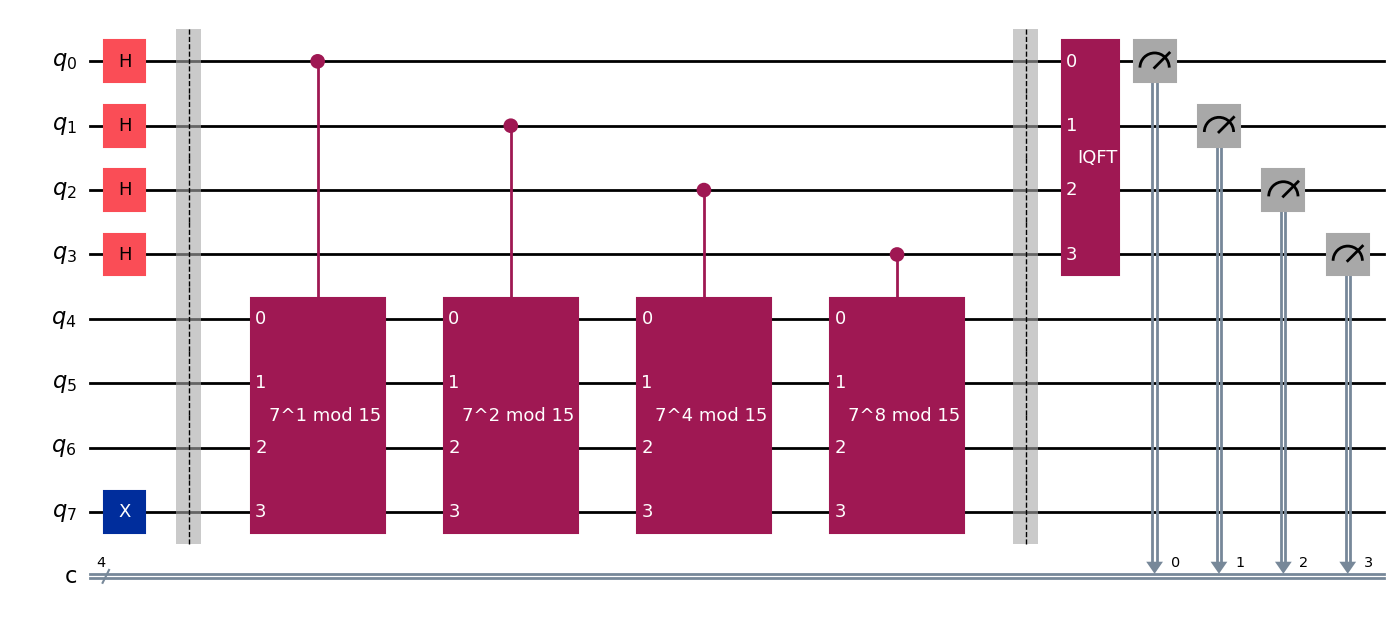

In [14]:
# Apply inverse QFT on the counting register
qft_dagger = QFT(n_count, inverse=True).to_gate()
qc.append(qft_dagger, range(n_count))

# Measure the counting register
qc.measure(range(n_count), range(n_count))
qc.draw('mpl', style='iqx')

In [ ]:
backend = Aer.get_backend('aer_simulator')
t_qc = transpile(qc, backend)

# The 'assemble' function is deprecated. We pass the circuit directly to run().
# All options like 'shots' and 'memory' go into the run() method.
result = backend.run(t_qc, shots=1, memory=True).result()
readings = result.get_memory()

# The rest of the cell remains the same
phase = int(readings[0], 2) / (2**n_count)
print(f"Measured phase = {phase}")

# Use continued fractions to find the period 'r'
frac = Fraction(phase).limit_denominator(N)
r = frac.denominator
print(f"The determined period r = {r}")

Measured phase = 0.5
The determined period r = 2


In [16]:
if r % 2 != 0:
    print("Period 'r' is odd. Algorithm fails for this 'a'.")
else:
    p = gcd(a**(r//2) + 1, N)
    q = gcd(a**(r//2) - 1, N)
    if p != 1 and p != N:
        print(f"Found factors: {p} and {N//p}")
    elif q != 1 and q != N:
        print(f"Found factors: {q} and {N//q}")
    else:
        print("Found trivial factors. Algorithm fails for this 'a'.")

Found factors: 3 and 5
